In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/Users/prishitasingh/Desktop/Machine Learning/pandas/mpg.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df=df.drop(columns=['name','origin'])
df['horsepower']=df['horsepower'].replace('?',np.nan)
df['horsepower']=df['horsepower'].fillna(df['horsepower'].median())
print(df.shape,"|",df.isnull().sum().sum(),"missing")
df.head()

(398, 7) | 0 missing


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [5]:
x=df.drop(columns= 'mpg')
y=df['mpg']
print(x.shape,y.shape)

(398, 6) (398,)


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape)

(318, 6) (80, 6)


In [7]:
print(y_train.shape,y_test.shape)

(318,) (80,)


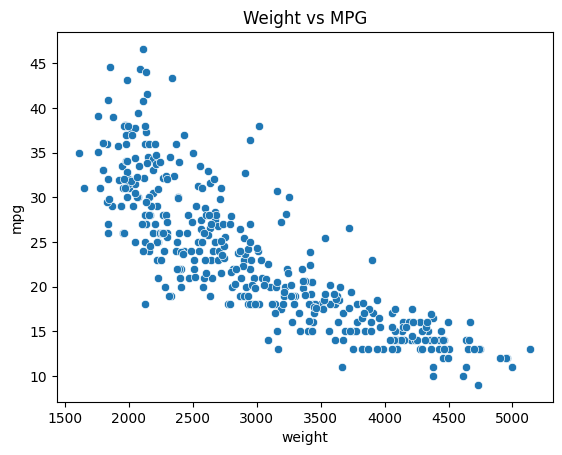

In [9]:
sns.scatterplot(x='weight',y='mpg',data=df)
plt.title("Weight vs MPG")
plt.show()



In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()    
model.fit(x_train[['weight']],y_train)
print("coef: ",model.coef_,"| intercept: ",model.intercept_)

coef:  [-0.00780524] | intercept:  46.7820633664505


In [11]:
print(model.score(x_test[['weight']],y_test))

0.7229710573030748


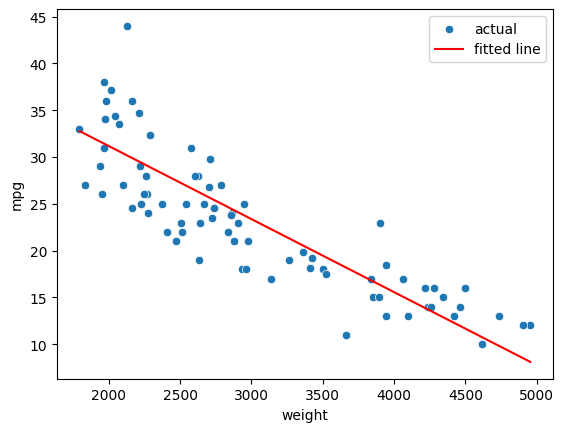

In [12]:
sns.scatterplot(x=x_test['weight'],y=y_test,label='actual')
sns.lineplot(x=x_test['weight'],y=model.predict(x_test[['weight']]),color='red',label='fitted line')
plt.show()

In [13]:
model_all=LinearRegression()
model_all.fit(x_train,y_train)
print(model_all.score(x_test,y_test))


0.824424533094336


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=model